# NSL-KDD Multiclass Intrusion Detection

**Goal:** 5-class classification — Normal, DoS, Probe, R2L, U2R  
**Models:** Random Forest, XGBoost, SVM  
**Key focus:** handling severe class imbalance and reporting per-class metrics (not just accuracy).

> ⚠️ Update `TRAIN_PATH` and `TEST_PATH` below to your local file locations.

## 1. Imports & Config

In [24]:
import numpy as np
import pickle
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, auc)
from sklearn.preprocessing import label_binarize
from imblearn.over_sampling import SMOTENC
from xgboost import XGBClassifier

plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 110
sns.set_style('whitegrid')

# === UPDATE THESE PATHS ===
TRAIN_PATH = r"S:\Downloads\Tanishq project\Tanishq project\KDDTrain+.txt"
TEST_PATH  = r"S:\Downloads\Tanishq project\Tanishq project\KDDTest+.txt"
RANDOM_STATE = 42

## 2. Load Data & Assign Feature Names

NSL-KDD has 41 features + label + difficulty score.

In [25]:
columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
    'wrong_fragment','urgent','hot','num_failed_logins','logged_in','num_compromised',
    'root_shell','su_attempted','num_root','num_file_creations','num_shells',
    'num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count',
    'srv_count','serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate',
    'same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count',
    'dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate',
    'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate',
    'label','difficulty'
]

df_train = pd.read_csv(TRAIN_PATH, names=columns)
df_test  = pd.read_csv(TEST_PATH,  names=columns)

df_train.drop(columns=['difficulty'], inplace=True)
df_test.drop(columns=['difficulty'], inplace=True)

print(f'Train shape: {df_train.shape}')
print(f'Test shape : {df_test.shape}')
df_train.head()

Train shape: (125973, 42)
Test shape : (22544, 42)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


## 3. Map Attack Types → 5 Categories

In [26]:
attack_map = {
    'normal':'Normal',
    # DoS
    'back':'DoS','land':'DoS','neptune':'DoS','pod':'DoS','smurf':'DoS','teardrop':'DoS',
    'apache2':'DoS','udpstorm':'DoS','processtable':'DoS','worm':'DoS','mailbomb':'DoS',
    # Probe
    'satan':'Probe','ipsweep':'Probe','nmap':'Probe','portsweep':'Probe',
    'mscan':'Probe','saint':'Probe',
    # R2L
    'guess_passwd':'R2L','ftp_write':'R2L','imap':'R2L','phf':'R2L','multihop':'R2L',
    'warezmaster':'R2L','warezclient':'R2L','spy':'R2L','xlock':'R2L','xsnoop':'R2L',
    'snmpguess':'R2L','snmpgetattack':'R2L','httptunnel':'R2L','sendmail':'R2L','named':'R2L',
    # U2R
    'buffer_overflow':'U2R','loadmodule':'U2R','rootkit':'U2R','perl':'U2R',
    'sqlattack':'U2R','xterm':'U2R','ps':'U2R'
}

df_train['attack_class'] = df_train['label'].map(attack_map)
df_test['attack_class']  = df_test['label'].map(attack_map)

# any unmapped -> drop (rare)
df_train.dropna(subset=['attack_class'], inplace=True)
df_test.dropna(subset=['attack_class'],  inplace=True)

print('Train class distribution:')
print(df_train['attack_class'].value_counts())
print('\nTest class distribution:')
print(df_test['attack_class'].value_counts())

Train class distribution:
attack_class
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64

Test class distribution:
attack_class
Normal    9711
DoS       7460
R2L       2885
Probe     2421
U2R         67
Name: count, dtype: int64


## 4. Class Distribution Plot

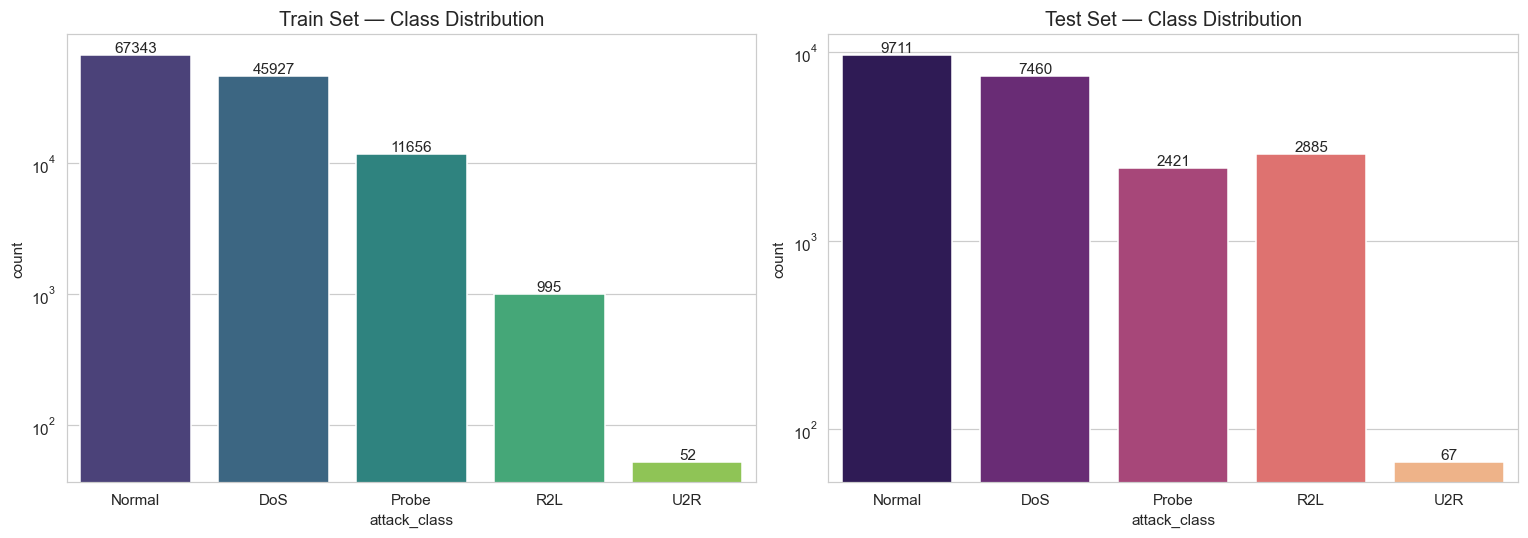

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order = ['Normal','DoS','Probe','R2L','U2R']

sns.countplot(x='attack_class', data=df_train, order=order, ax=axes[0], palette='viridis')
axes[0].set_title('Train Set — Class Distribution', fontsize=13)
axes[0].set_yscale('log')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=10)

sns.countplot(x='attack_class', data=df_test, order=order, ax=axes[1], palette='magma')
axes[1].set_title('Test Set — Class Distribution', fontsize=13)
axes[1].set_yscale('log')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=10)

plt.tight_layout(); plt.show()

In [28]:
df_tr, df_val = train_test_split(
    df_train,
    test_size=0.15,
    stratify=df_train['attack_class'],
    random_state=RANDOM_STATE
)

print(f'Train shape: {df_tr.shape[0]}')
print(f'Validation shape: {df_val.shape[0]}')
print('\n Train Class Distribution: ')
print(df_tr['attack_class'].value_counts())
print('\n Validation Class Distribution: ')
print(df_val['attack_class'].value_counts())

Train shape: 107077
Validation shape: 18896

 Train Class Distribution: 
attack_class
Normal    57241
DoS       39038
Probe      9908
R2L         846
U2R          44
Name: count, dtype: int64

 Validation Class Distribution: 
attack_class
Normal    10102
DoS        6889
Probe      1748
R2L         149
U2R           8
Name: count, dtype: int64


## 5. Preprocessing

- One-hot encode `protocol_type`, `service`, `flag`
- Align train/test columns (test may lack some services)
- Scale numeric features
- Label-encode target

In [29]:
cat_cols = ['protocol_type','service','flag']

X_tr_raw = df_train.drop(columns=['label','attack_class']).reset_index(drop=True)
y_tr_raw = df_train['attack_class'].reset_index(drop=True)

X_val_raw = df_val.drop(columns=['label','attack_class']).reset_index(drop=True)
y_val_raw = df_val['attack_class'].reset_index(drop=True)

X_test_raw  = df_test.drop(columns=['label','attack_class']).reset_index(drop=True)
y_test_raw  = df_test['attack_class'].reset_index(drop=True)

# one-hot encode
cat_indices = [X_tr_raw.columns.get_loc(col) for col in cat_cols]
print(f'Categorical column indices for SMOTENC: {cat_indices}')

# Moderate oversampling — NOT full balance. Bring minorities up to a
# fraction of the majority rather than 1:1 parity. Tune these numbers;
# start conservative and check val recall before pushing further.
majority_count = y_tr_raw.value_counts().max()

sampling_strategy = {
    'R2L': int(majority_count * 0.15),   # ~10K instead of full 67K
    'U2R': int(majority_count * 0.05),   # ~3.3K instead of full 67K
    'Probe': int(majority_count * 0.5),  # mild boost, Probe isn't as starved
}
# Only include classes that are actually below the target — SMOTENC
# will error if you ask it to "oversample" a class that's already larger
current_counts = y_tr_raw.value_counts().to_dict()
sampling_strategy = {
    k: v for k, v in sampling_strategy.items()
    if v > current_counts.get(k, 0)
}
print('SMOTENC target counts:', sampling_strategy)

# k_neighbors must be < smallest class size being oversampled
min_class_size = min(current_counts[c] for c in sampling_strategy)
k = max(1, min(5, min_class_size - 1))

smote_nc = SMOTENC(
    categorical_features=cat_indices,
    sampling_strategy=sampling_strategy,
    k_neighbors=k,
    random_state=RANDOM_STATE
)

X_tr_bal_raw, y_tr_bal = smote_nc.fit_resample(X_tr_raw, y_tr_raw)

print('\nBefore SMOTENC:')
print(y_tr_raw.value_counts())
print('\nAfter SMOTENC:')
print(pd.Series(y_tr_bal).value_counts())


# One-hot encode categoricals AFTER SMOTENC (dummy columns now clean 0/1)
X_tr_enc = pd.get_dummies(X_tr_bal_raw, columns=cat_cols)
X_val_enc = pd.get_dummies(X_val_raw, columns=cat_cols)
X_test_enc = pd.get_dummies(X_test_raw, columns=cat_cols)

# Align columns — train defines the schema, val/test conform to it
X_tr_enc, X_val_enc = X_tr_enc.align(X_val_enc, join='left', axis=1, fill_value=0)
X_tr_enc, X_test_enc = X_tr_enc.align(X_test_enc, join='left', axis=1, fill_value=0)
# Re-align val/test to each other in case columns diverged
X_val_enc = X_val_enc.reindex(columns=X_tr_enc.columns, fill_value=0)
X_test_enc = X_test_enc.reindex(columns=X_tr_enc.columns, fill_value=0)

# Scale — fit on train (post-SMOTENC) only
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr_enc)
X_val_s = scaler.transform(X_val_enc)
X_test_s = scaler.transform(X_test_enc)

# Encode target — fit on train labels only, classes are the same 5 categories
le = LabelEncoder()
y_tr_bal_enc = le.fit_transform(y_tr_bal)
y_val_enc = le.transform(y_val_raw)
y_test_enc = le.transform(y_test_raw)
class_names = le.classes_

print(f'\nFeature count after encoding: {X_tr_s.shape[1]}')
print(f'Classes: {list(class_names)}')


Categorical column indices for SMOTENC: [1, 2, 3]
SMOTENC target counts: {'R2L': 10101, 'U2R': 3367, 'Probe': 33671}

Before SMOTENC:
attack_class
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64

After SMOTENC:
attack_class
Normal    67343
DoS       45927
Probe     33671
R2L       10101
U2R        3367
Name: count, dtype: int64

Feature count after encoding: 122
Classes: ['DoS', 'Normal', 'Probe', 'R2L', 'U2R']


## 6. SMOTE — Handle Class Imbalance (train only)

In [30]:
# # k_neighbors must be < smallest class count; U2R is tiny
# min_count = pd.Series(y_train_enc).value_counts().min()
# k = max(1, min(5, min_count - 1))

# sm = SMOTE(random_state=RANDOM_STATE, k_neighbors=k)
# X_tr_s, y_tr_bal_enc = sm.fit_resample(X_train_s, y_train_enc)

# print('Before SMOTE:')
# print(pd.Series(y_train_enc).value_counts().rename(index=dict(enumerate(class_names))))
# print('\nAfter SMOTE:')
# print(pd.Series(y_tr_bal_enc).value_counts().rename(index=dict(enumerate(class_names))))

## 7. Helper — Evaluation Function

In [31]:
def evaluate_model(model, X_te, y_te, name):
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)

    print(f'===== {name} — Classification Report =====')
    print(classification_report(y_te, y_pred, target_names=class_names, digits=4, zero_division=0))

    # Confusion matrix
    cm = confusion_matrix(y_te, y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[0],
                cbar=False, annot_kws={'size':12})
    axes[0].set_title(f'{name} — Confusion Matrix', fontsize=13)
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

    # ROC curves (one-vs-rest)
    y_bin = label_binarize(y_te, classes=list(range(len(class_names))))
    colors = sns.color_palette('tab10', len(class_names))
    for i, cname in enumerate(class_names):
        if y_bin[:, i].sum() == 0:
            continue
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
        axes[1].plot(fpr, tpr, color=colors[i], lw=2,
                     label=f'{cname} (AUC = {auc(fpr, tpr):.3f})')
    axes[1].plot([0,1],[0,1],'k--', lw=1)
    axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'{name} — ROC Curves (One-vs-Rest)', fontsize=13)
    axes[1].legend(loc='lower right', fontsize=10)

    plt.tight_layout(); plt.show()

    try:
        macro_auc = roc_auc_score(y_te, y_proba, multi_class='ovr', average='macro')
        print(f'Macro ROC-AUC (OvR): {macro_auc:.4f}')
    except Exception as e:
        print(f'AUC skipped: {e}')

## 8. Random Forest

===== Random Forest — Classification Report =====
              precision    recall  f1-score   support

         DoS     0.9617    0.7845    0.8641      7460
      Normal     0.6637    0.9721    0.7888      9711
       Probe     0.8332    0.6543    0.7330      2421
         R2L     0.9681    0.1050    0.1895      2885
         U2R     0.5455    0.1791    0.2697        67

    accuracy                         0.7626     22544
   macro avg     0.7944    0.5390    0.5690     22544
weighted avg     0.8191    0.7626    0.7295     22544



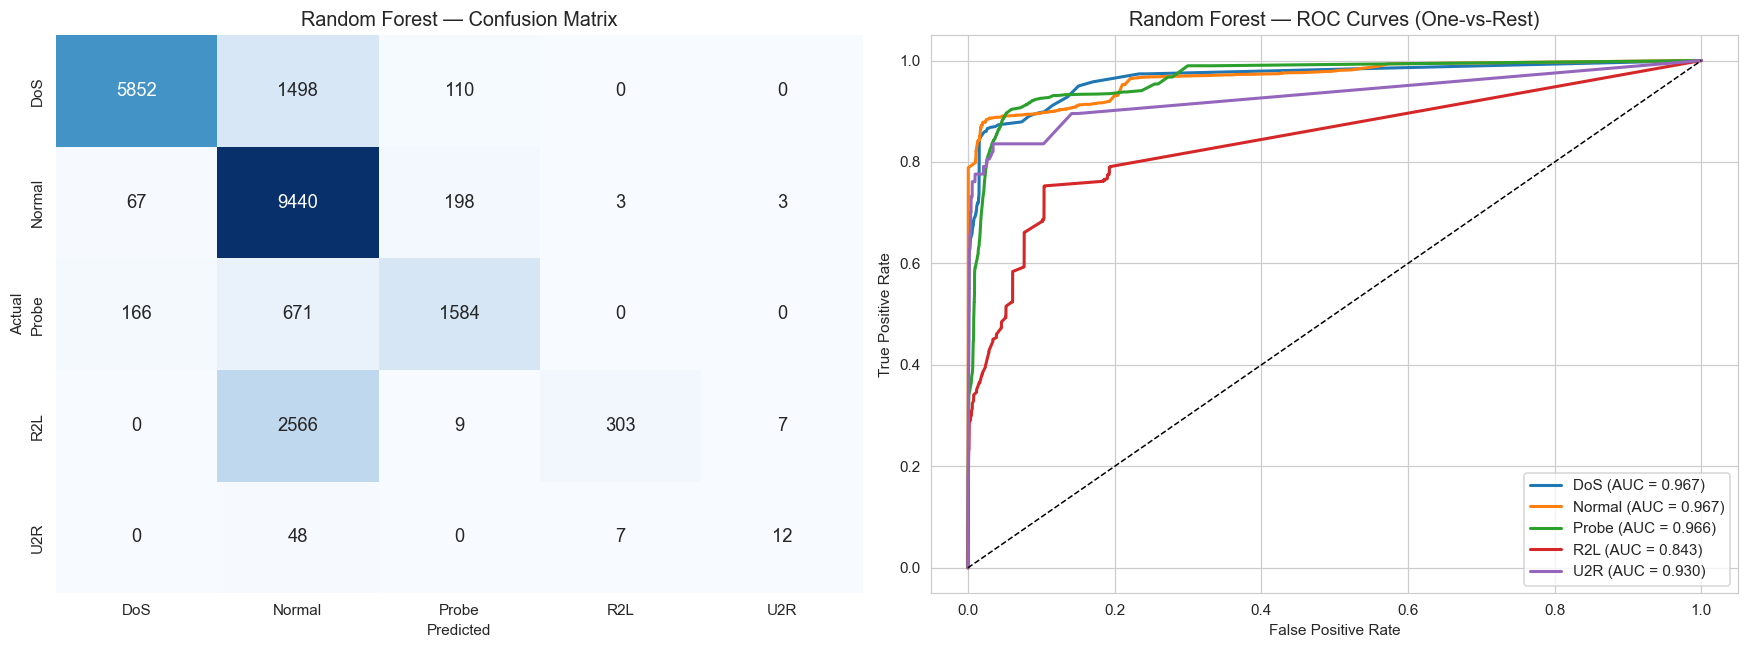

Macro ROC-AUC (OvR): 0.9345


In [32]:
rf = RandomForestClassifier(n_estimators=100, max_depth=25, n_jobs=-1,
                            random_state=RANDOM_STATE, class_weight='balanced')
rf.fit(X_tr_s, y_tr_bal_enc)
evaluate_model(rf, X_test_s, y_test_enc, 'Random Forest')

## 9. XGBoost

===== XGBoost — Classification Report =====
              precision    recall  f1-score   support

         DoS     0.9655    0.8259    0.8903      7460
      Normal     0.6800    0.9720    0.8002      9711
       Probe     0.7921    0.6357    0.7053      2421
         R2L     0.9751    0.1085    0.1953      2885
         U2R     0.7895    0.2239    0.3488        67

    accuracy                         0.7748     22544
   macro avg     0.8404    0.5532    0.5880     22544
weighted avg     0.8246    0.7748    0.7411     22544



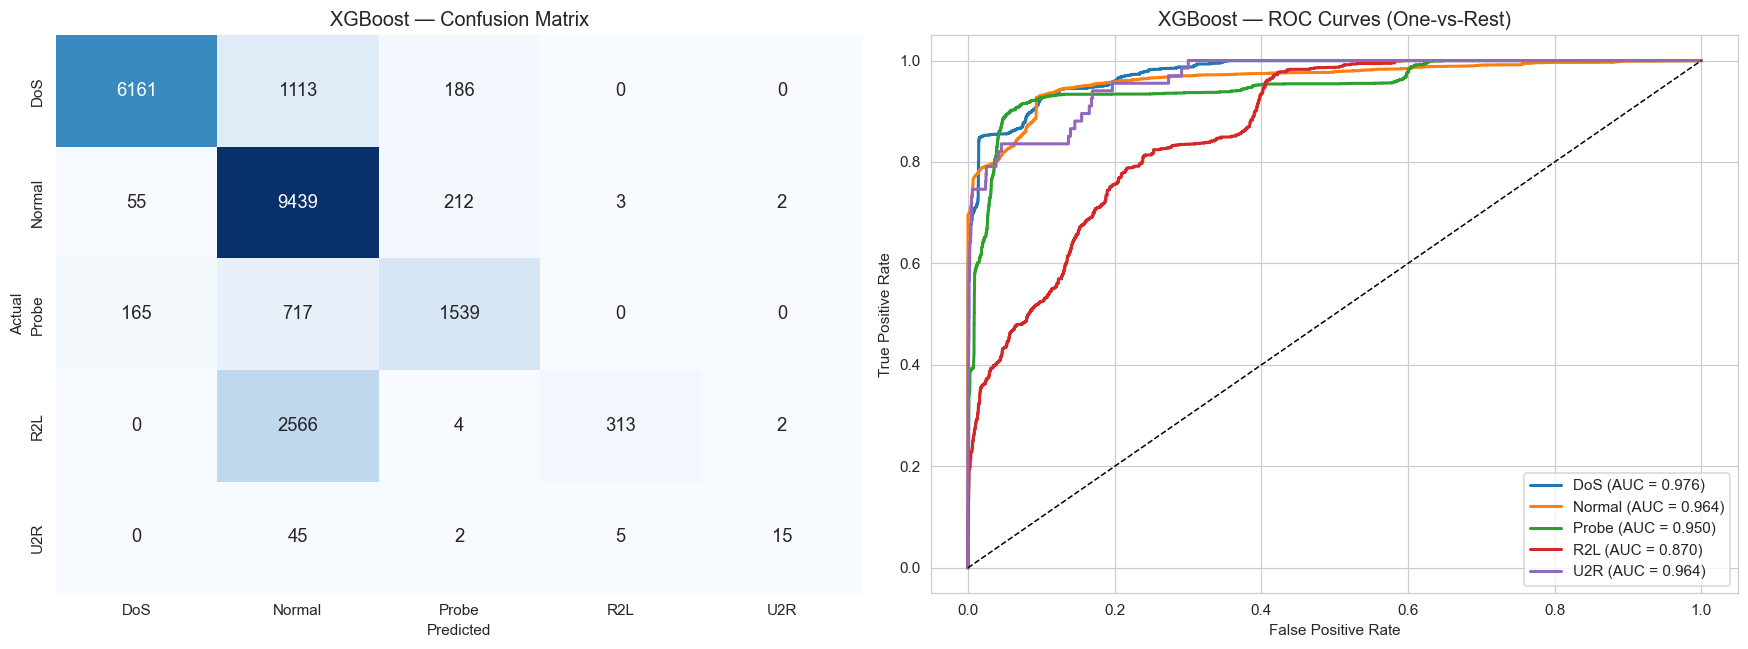

Macro ROC-AUC (OvR): 0.9449


In [33]:
xgb = XGBClassifier(n_estimators=200, max_depth=8, learning_rate=0.1,
                    objective='multi:softprob', num_class=len(class_names),
                    eval_metric='mlogloss', n_jobs=-1, random_state=RANDOM_STATE,
                    tree_method='hist')
xgb.fit(X_tr_s, y_tr_bal_enc)
evaluate_model(xgb, X_test_s, y_test_enc, 'XGBoost')

## 10. SVM

> SVM is slow on 100K+ rows. We subsample the balanced training set for tractable runtime.

===== SVM (RBF) — Classification Report =====
              precision    recall  f1-score   support

         DoS     0.8779    0.7983    0.8362      7460
      Normal     0.7027    0.9169    0.7956      9711
       Probe     0.7914    0.6708    0.7261      2421
         R2L     0.7751    0.1314    0.2247      2885
         U2R     0.0583    0.4776    0.1039        67

    accuracy                         0.7494     22544
   macro avg     0.6411    0.5990    0.5373     22544
weighted avg     0.7776    0.7494    0.7265     22544



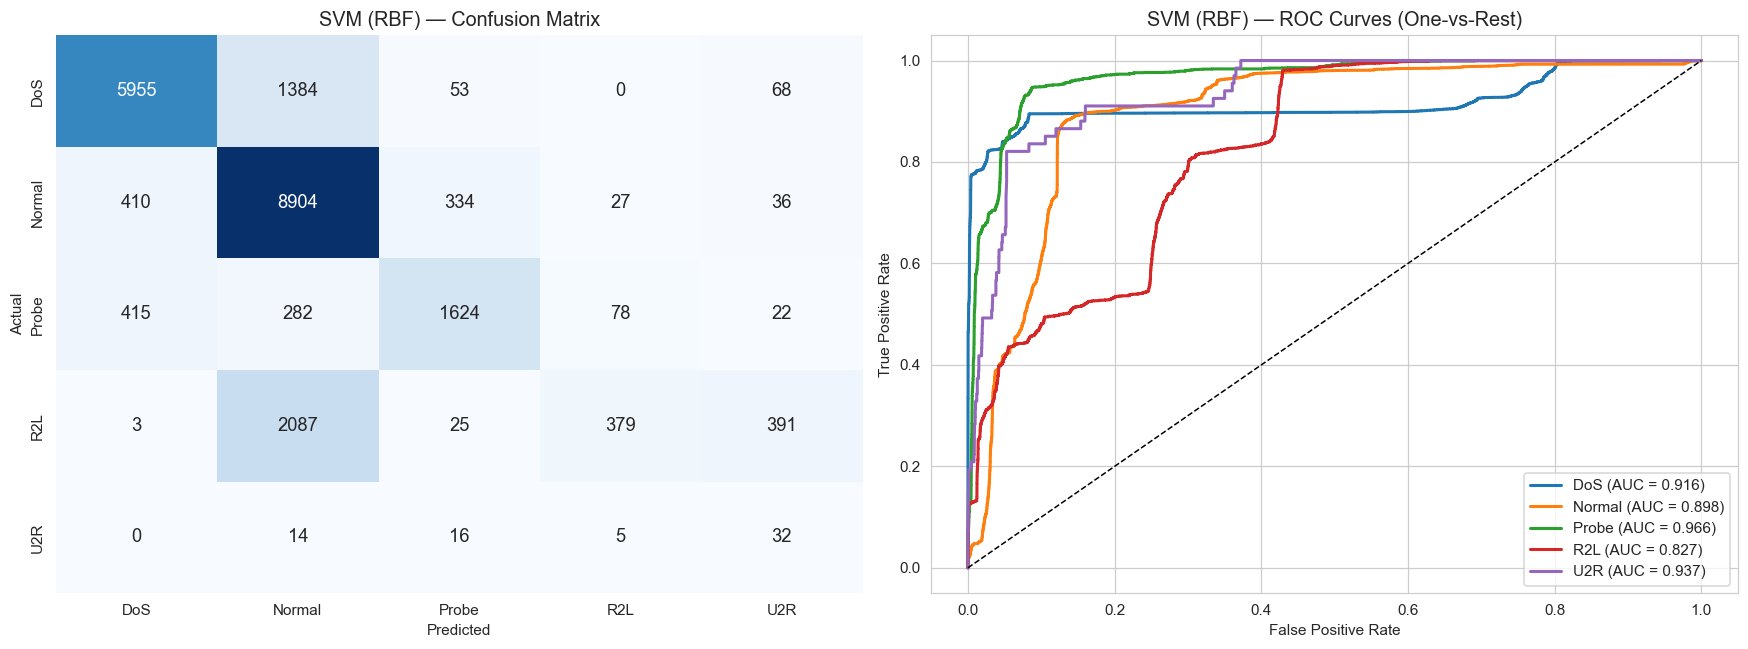

Macro ROC-AUC (OvR): 0.9090


In [34]:
# Subsample for SVM (stratified) — keeps all classes represented
from sklearn.model_selection import train_test_split
SVM_SAMPLES = 30000
if len(X_tr_s) > SVM_SAMPLES:
    X_svm, _, y_svm, _ = train_test_split(X_tr_s, y_tr_bal_enc,
                                          train_size=SVM_SAMPLES,
                                          stratify=y_tr_bal_enc,
                                          random_state=RANDOM_STATE)
else:
    X_svm, y_svm = X_tr_s, y_tr_bal_enc

svm = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True,
          random_state=RANDOM_STATE, class_weight='balanced')
svm.fit(X_svm, y_svm)
evaluate_model(svm, X_test_s, y_test_enc, 'SVM (RBF)')

## 11. Model Comparison

               Accuracy  Macro F1  Weighted F1  Macro ROC-AUC
Model                                                        
Random Forest    0.7626    0.5690       0.7295         0.9345
XGBoost          0.7748    0.5880       0.7411         0.9449
SVM              0.7494    0.5373       0.7265         0.9090


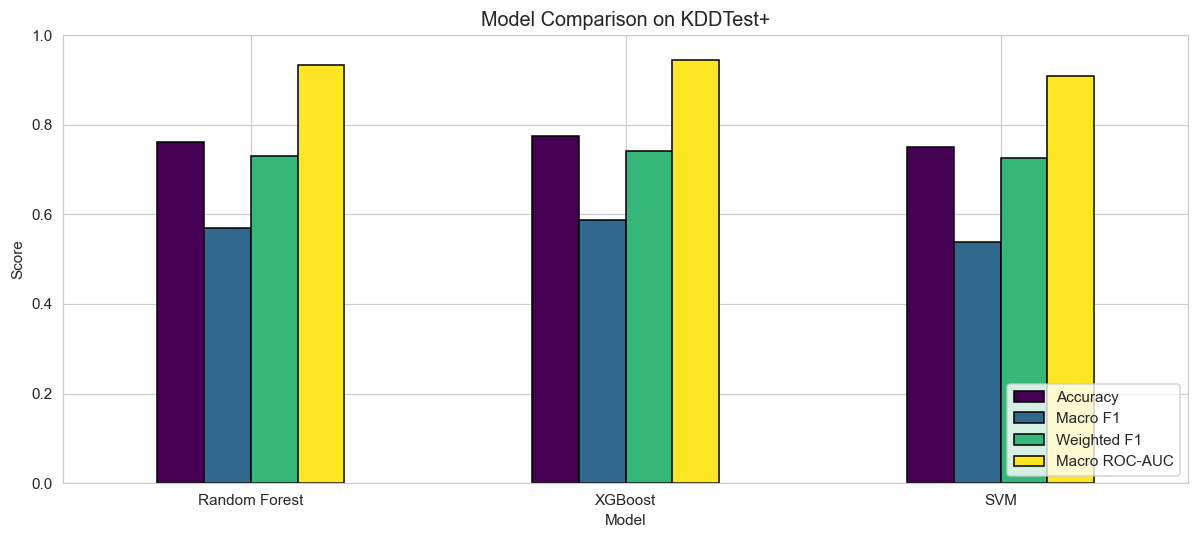

In [35]:
from sklearn.metrics import f1_score, accuracy_score

results = []
for name, model in [('Random Forest', rf), ('XGBoost', xgb), ('SVM', svm)]: #, ('RandomisedSearch', rs_xgb)]:
    y_pred = model.predict(X_test_s)
    y_proba = model.predict_proba(X_test_s)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test_enc, y_pred),
        'Macro F1': f1_score(y_test_enc, y_pred, average='macro', zero_division=0),
        'Weighted F1': f1_score(y_test_enc, y_pred, average='weighted', zero_division=0),
        'Macro ROC-AUC': roc_auc_score(y_test_enc, y_proba, multi_class='ovr', average='macro')
    })

results_df = pd.DataFrame(results).set_index('Model').round(4)
print(results_df)

fig, ax = plt.subplots(figsize=(11, 5))
results_df.plot(kind='bar', ax=ax, colormap='viridis', edgecolor='black')
ax.set_title('Model Comparison on KDDTest+', fontsize=13)
ax.set_ylabel('Score'); ax.set_ylim(0, 1)
ax.legend(loc='lower right'); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

## Notes

- **Accuracy is misleading here** — always look at per-class recall for R2L and U2R.
- **KDDTest+ contains unseen attack types** not in the train set — expect lower test scores than train CV. That's the point of NSL-KDD.
- **Next steps:** feature importance from XGBoost, hyperparameter tuning, hierarchical (binary→attack-type) classifier, generalization test on CICIDS2017.

## 12. Hierarchical Two-Stage Classifier
Binary Normal-vs-Attack stage, followed by a 4-way classifier among attack types only.



In [36]:
## 12. Hierarchical Two-Stage Classifier
# Stage 1: Normal vs Attack (binary) — Stage 2: DoS/Probe/R2L/U2R (4-way, attack-only)

normal_idx = list(class_names).index('Normal')

y_tr_binary = (y_tr_bal_enc != normal_idx).astype(int)
y_val_binary = (y_val_enc != normal_idx).astype(int)
y_test_binary = (y_test_enc != normal_idx).astype(int)

stage1_model = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    eval_metric='logloss', n_jobs=-1, random_state=RANDOM_STATE,
    tree_method='hist'
)
stage1_model.fit(X_tr_s, y_tr_binary)

# Quick sanity check on stage 1 alone
pred_binary_val = stage1_model.predict(X_val_s)
print('===== Stage 1 (Normal vs Attack) — Validation =====')
print(classification_report(y_val_binary, pred_binary_val,
                             target_names=['Normal', 'Attack'], digits=4))

===== Stage 1 (Normal vs Attack) — Validation =====
              precision    recall  f1-score   support

      Normal     1.0000    0.9995    0.9998     10102
      Attack     0.9994    1.0000    0.9997      8794

    accuracy                         0.9997     18896
   macro avg     0.9997    0.9998    0.9997     18896
weighted avg     0.9997    0.9997    0.9997     18896



In [37]:
# Train stage 2 ONLY on non-Normal samples from the resampled training set
attack_mask_tr = y_tr_bal_enc != normal_idx
X_tr_attacks = X_tr_s[attack_mask_tr]
y_tr_attacks = y_tr_bal_enc[attack_mask_tr]

# Re-map labels to a contiguous 0..3 range for stage 2 (excluding Normal)
attack_classes = [c for c in class_names if c != 'Normal']
attack_class_to_new = {le.transform([c])[0]: i for i, c in enumerate(attack_classes)}
new_to_orig = {v: k for k, v in attack_class_to_new.items()}

y_tr_attacks_remapped = np.array([attack_class_to_new[y] for y in y_tr_attacks])

print('Stage 2 training class distribution:')
print(pd.Series(y_tr_attacks_remapped).value_counts().rename(
    index=dict(enumerate(attack_classes))))

stage2_model = XGBClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.1,
    objective='multi:softprob', num_class=len(attack_classes),
    eval_metric='mlogloss', n_jobs=-1, random_state=RANDOM_STATE,
    tree_method='hist'
)
stage2_model.fit(X_tr_attacks, y_tr_attacks_remapped)

Stage 2 training class distribution:
DoS      45927
Probe    33671
R2L      10101
U2R       3367
Name: count, dtype: int64


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import l

In [38]:
def hierarchical_predict(X, stage1, stage2, normal_idx, attack_classes, new_to_orig, n_classes):
    """
    Returns (y_pred, y_proba) in the ORIGINAL 5-class label space,
    so it can be dropped into the existing evaluate_model() function.
    """
    n_samples = X.shape[0]

    # Stage 1 probabilities: P(Normal), P(Attack)
    stage1_proba = stage1.predict_proba(X)  # shape (n, 2)
    p_normal = stage1_proba[:, 0]
    p_attack = stage1_proba[:, 1]

    # Stage 2 probabilities computed for ALL samples (cheap, avoids masking headaches)
    stage2_proba = stage2.predict_proba(X)  # shape (n, 4)

    # Compose into full 5-class proba matrix:
    # P(class=Normal) = P(stage1=Normal)
    # P(class=attack_i) = P(stage1=Attack) * P(stage2=attack_i | Attack)
    y_proba = np.zeros((n_samples, n_classes))
    y_proba[:, normal_idx] = p_normal

    for stage2_idx, orig_idx in new_to_orig.items():
        y_proba[:, orig_idx] = p_attack * stage2_proba[:, stage2_idx]

    y_pred = np.argmax(y_proba, axis=1)
    return y_pred, y_proba


y_pred_hier, y_proba_hier = hierarchical_predict(
    X_val_s, stage1_model, stage2_model, normal_idx,
    attack_classes, new_to_orig, n_classes=len(class_names)
)

print('===== Hierarchical Model — Validation =====')
print(classification_report(y_val_enc, y_pred_hier, target_names=class_names,
                             digits=4, zero_division=0))

===== Hierarchical Model — Validation =====
              precision    recall  f1-score   support

         DoS     0.9999    1.0000    0.9999      6889
      Normal     1.0000    0.9996    0.9998     10102
       Probe     1.0000    1.0000    1.0000      1748
         R2L     0.9933    1.0000    0.9967       149
         U2R     0.8000    1.0000    0.8889         8

    accuracy                         0.9998     18896
   macro avg     0.9586    0.9999    0.9771     18896
weighted avg     0.9998    0.9998    0.9998     18896



===== Hierarchical XGBoost (Validation) — Classification Report =====
              precision    recall  f1-score   support

         DoS     0.9999    1.0000    0.9999      6889
      Normal     1.0000    0.9996    0.9998     10102
       Probe     1.0000    1.0000    1.0000      1748
         R2L     0.9933    1.0000    0.9967       149
         U2R     0.8000    1.0000    0.8889         8

    accuracy                         0.9998     18896
   macro avg     0.9586    0.9999    0.9771     18896
weighted avg     0.9998    0.9998    0.9998     18896



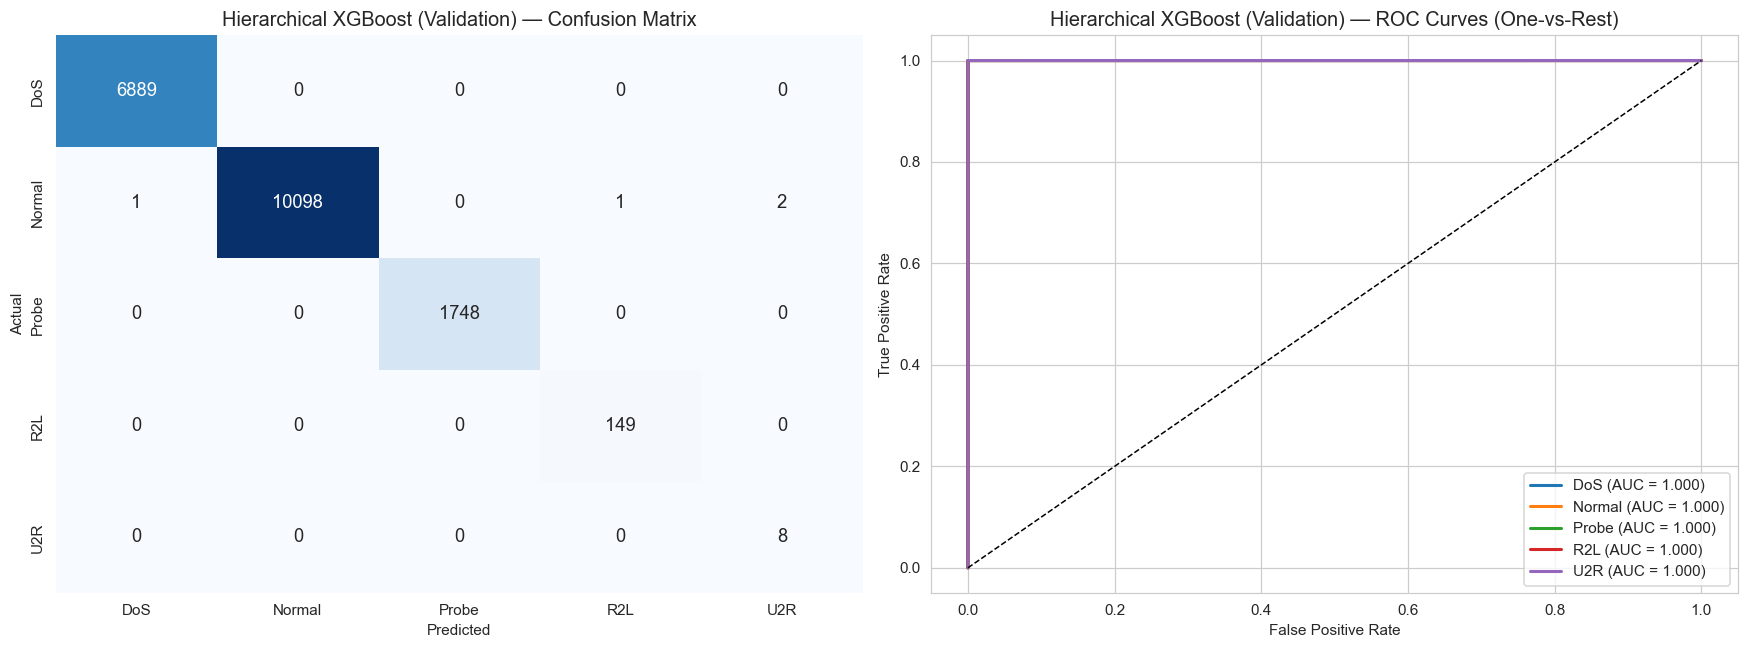

Macro ROC-AUC (OvR): 1.0000


In [39]:
def evaluate_hierarchical(stage1, stage2, X_te, y_te, name,
                           normal_idx=normal_idx, attack_classes=attack_classes,
                           new_to_orig=new_to_orig, n_classes=None):
    n_classes = n_classes or len(class_names)
    y_pred, y_proba = hierarchical_predict(X_te, stage1, stage2, normal_idx,
                                            attack_classes, new_to_orig, n_classes)

    print(f'===== {name} — Classification Report =====')
    print(classification_report(y_te, y_pred, target_names=class_names,
                                 digits=4, zero_division=0))

    cm = confusion_matrix(y_te, y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[0],
                cbar=False, annot_kws={'size': 12})
    axes[0].set_title(f'{name} — Confusion Matrix', fontsize=13)
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

    y_bin = label_binarize(y_te, classes=list(range(len(class_names))))
    colors = sns.color_palette('tab10', len(class_names))
    for i, cname in enumerate(class_names):
        if y_bin[:, i].sum() == 0:
            continue
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
        axes[1].plot(fpr, tpr, color=colors[i], lw=2,
                      label=f'{cname} (AUC = {auc(fpr, tpr):.3f})')
    axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'{name} — ROC Curves (One-vs-Rest)', fontsize=13)
    axes[1].legend(loc='lower right', fontsize=10)

    plt.tight_layout(); plt.show()

    try:
        macro_auc = roc_auc_score(y_te, y_proba, multi_class='ovr', average='macro')
        print(f'Macro ROC-AUC (OvR): {macro_auc:.4f}')
    except Exception as e:
        print(f'AUC skipped: {e}')

    return y_pred, y_proba


# Run on validation first to sanity check before touching test set
_ = evaluate_hierarchical(stage1_model, stage2_model, X_val_s, y_val_enc,
                           'Hierarchical XGBoost (Validation)')

===== Hierarchical XGBoost (Test) — Classification Report =====
              precision    recall  f1-score   support

         DoS     0.9644    0.8450    0.9008      7460
      Normal     0.6987    0.9713    0.8127      9711
       Probe     0.8093    0.7080    0.7552      2421
         R2L     0.9720    0.1203    0.2141      2885
         U2R     0.7188    0.3433    0.4646        67

    accuracy                         0.7905     22544
   macro avg     0.8326    0.5976    0.6295     22544
weighted avg     0.8335    0.7905    0.7580     22544



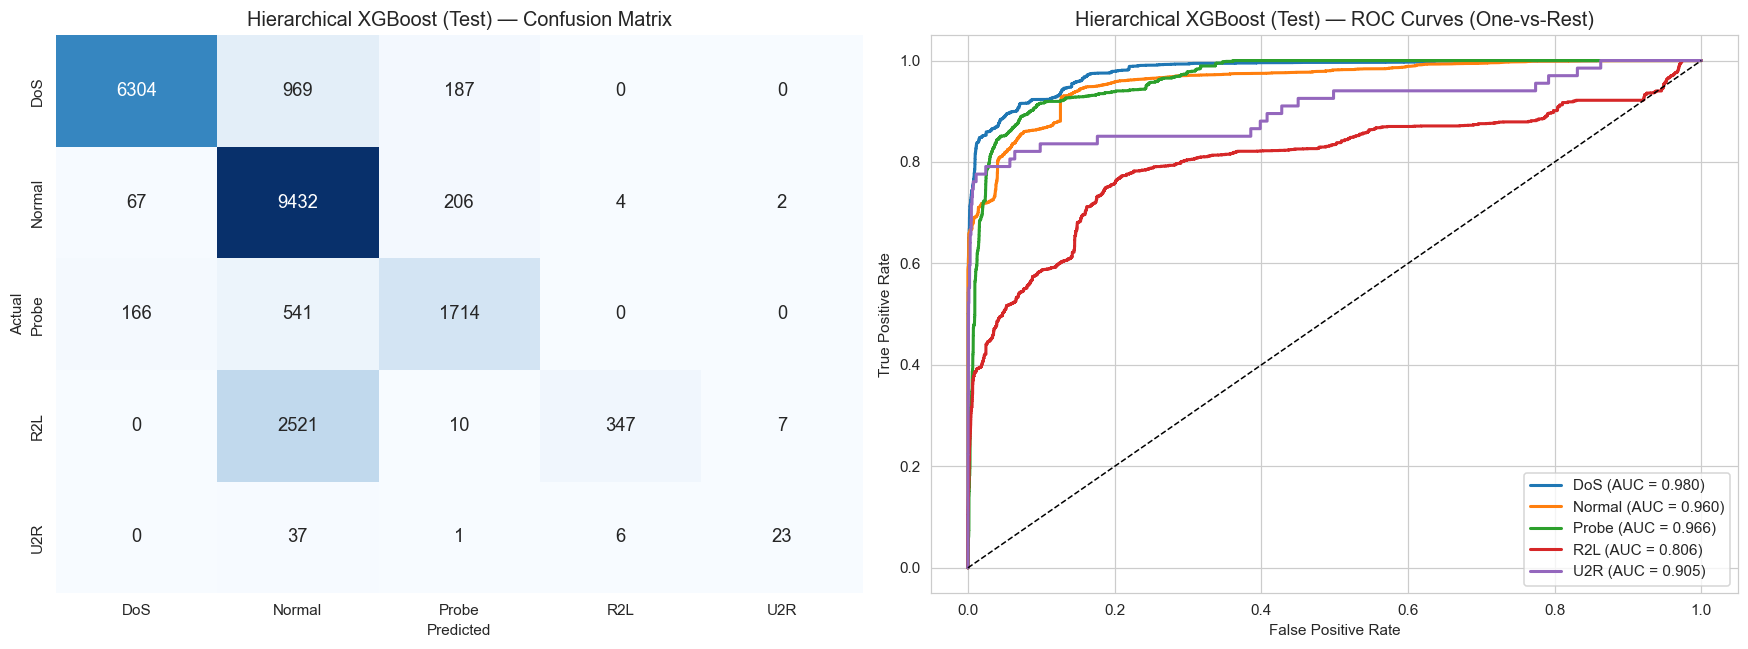

Macro ROC-AUC (OvR): 0.9236


In [40]:
y_pred_hier_test, y_proba_hier_test = evaluate_hierarchical(
    stage1_model, stage2_model, X_test_s, y_test_enc,
    'Hierarchical XGBoost (Test)'
)

In [41]:
comparison_rows = []
for name, y_true, y_pred, y_proba in [
    ('Flat XGBoost', y_test_enc, xgb.predict(X_test_s), xgb.predict_proba(X_test_s)),
    ('Hierarchical XGBoost', y_test_enc, y_pred_hier_test, y_proba_hier_test),
]:
    report = classification_report(y_true, y_pred, target_names=class_names,
                                    output_dict=True, zero_division=0)
    comparison_rows.append({
        'Model': name,
        'R2L Recall': report['R2L']['recall'],
        'R2L Precision': report['R2L']['precision'],
        'U2R Recall': report['U2R']['recall'],
        'U2R Precision': report['U2R']['precision'],
        'Macro F1': report['macro avg']['f1-score'],
        'Accuracy': report['accuracy'],
    })

comparison_df = pd.DataFrame(comparison_rows).set_index('Model').round(4)
print(comparison_df)

                      R2L Recall  R2L Precision  U2R Recall  U2R Precision  \
Model                                                                        
Flat XGBoost              0.1085         0.9751      0.2239         0.7895   
Hierarchical XGBoost      0.1203         0.9720      0.3433         0.7188   

                      Macro F1  Accuracy  
Model                                     
Flat XGBoost            0.5880    0.7748  
Hierarchical XGBoost    0.6295    0.7905  


## 13. Hyperparameter Tuning (XGBoost)
Using `RandomizedSearchCV` is a more efficient way to improve the F1-score than manual tuning.

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best Parameters: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.9}
===== Optimized XGBoost — Classification Report =====
              precision    recall  f1-score   support

         DoS     0.9645    0.8444    0.9004      7460
      Normal     0.6705    0.9726    0.7938      9711
       Probe     0.8438    0.6022    0.7028      2421
         R2L     0.9842    0.0648    0.1216      2885
         U2R     0.7778    0.1045    0.1842        67

    accuracy                         0.7716     22544
   macro avg     0.8481    0.5177    0.5406     22544
weighted avg     0.8269    0.7716    0.7315     22544



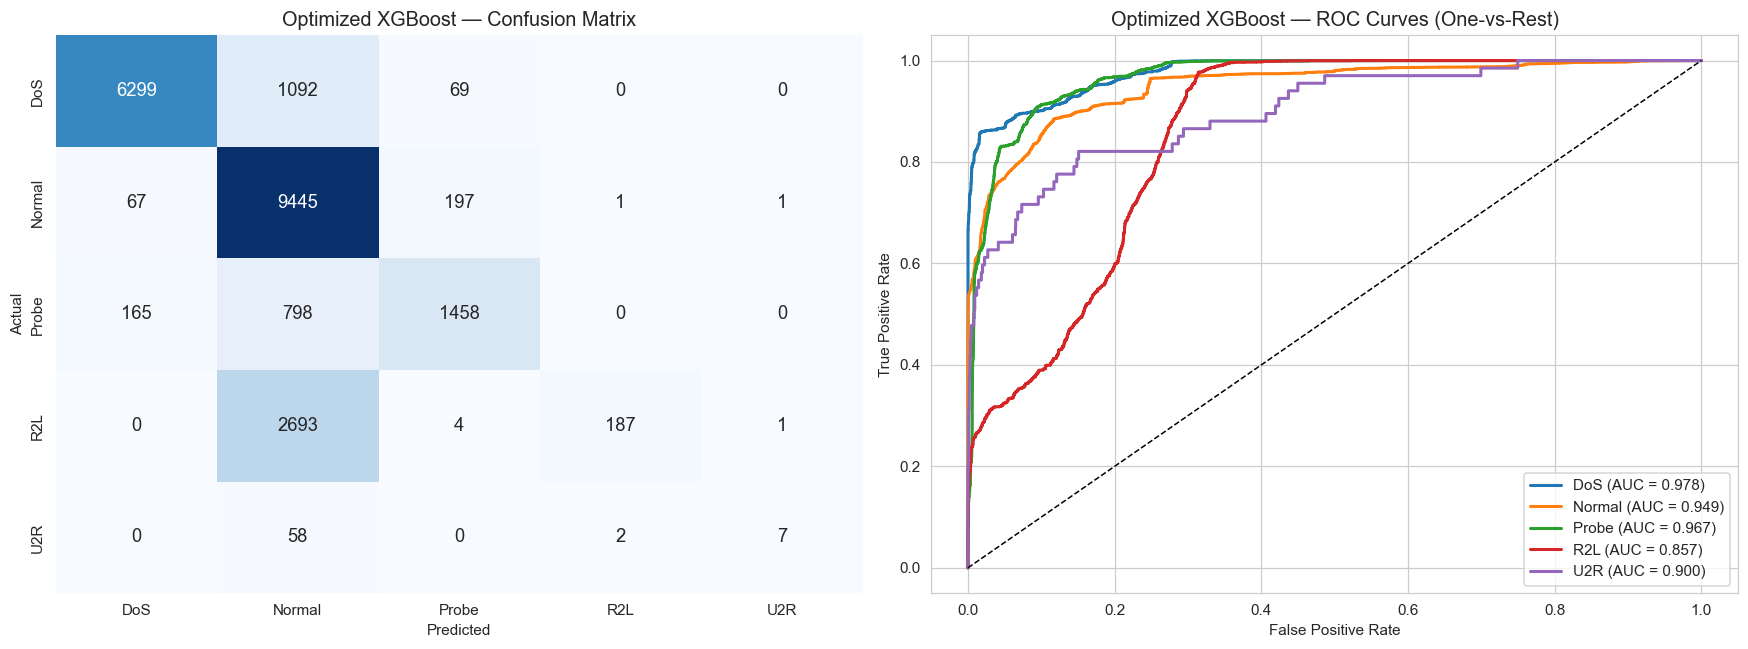

Macro ROC-AUC (OvR): 0.9303


In [42]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 8, 12],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

# We use a smaller subset of balanced data for speed in this demo
rs_xgb = RandomizedSearchCV(XGBClassifier(objective='multi:softprob', eval_metric='mlogloss', n_jobs=-1, random_state=RANDOM_STATE),
                            param_distributions=param_grid, n_iter=5, cv=3, verbose=1, n_jobs=-1, scoring='f1_macro')

rs_xgb.fit(X_tr_s[:20000], y_tr_bal_enc[:20000])
print(f"Best Parameters: {rs_xgb.best_params_}")

# Evaluate optimized model
evaluate_model(rs_xgb.best_estimator_, X_test_s, y_test_enc, 'Optimized XGBoost')

## 14. Improving Results: Feature Importance
We will analyze which features contribute most to the XGBoost model to see if we can simplify the model or remove noise.

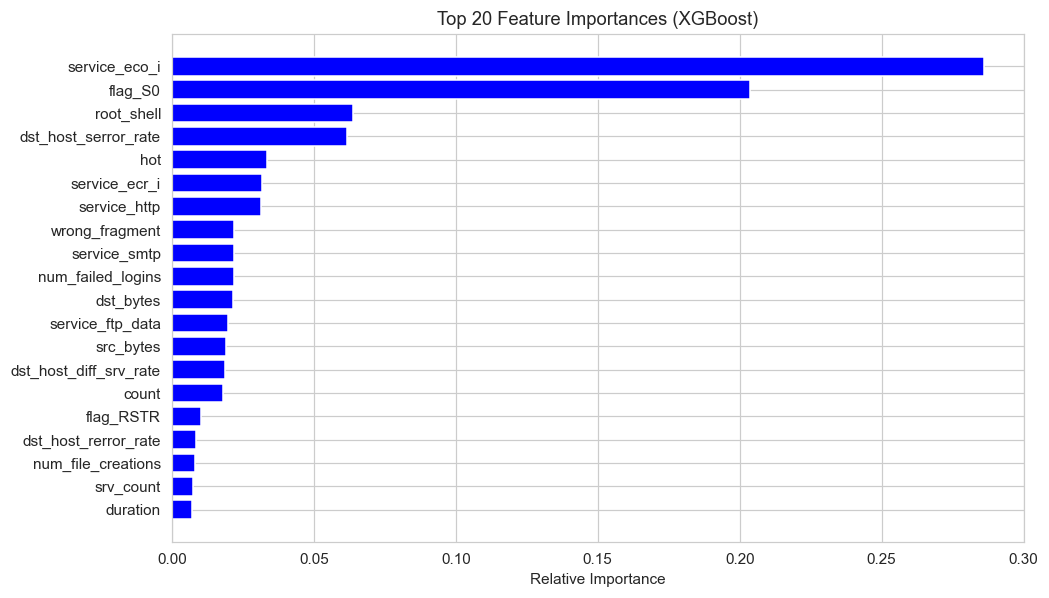

In [43]:
importances = xgb.feature_importances_
indices = np.argsort(importances)[-20:] # Top 20

plt.figure(figsize=(10, 6))
plt.title('Top 20 Feature Importances (XGBoost)')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [X_tr_enc.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

In [ ]:
Path('models').mkdir(exist_ok=True)
Path('results').mkdir(exist_ok=True)

pickle.dump(rf,     open('models/random_forest.pkl', 'wb'))
pickle.dump(xgb,    open('models/xgboost.pkl', 'wb'))
pickle.dump(svm,    open('models/svm_(rbf).pkl', 'wb'))
pickle.dump(scaler, open('models/scaler.pkl', 'wb'))
pickle.dump(le,     open('models/label_encoder.pkl', 'wb'))
pickle.dump(rs_xgb, open('models/random_search_xgboost.pkl', 'wb'))

hier_dict = {
    "stage1_model":   stage1_model,
    "stage2_model":   stage2_model,
    "normal_idx":     normal_idx,
    "attack_classes": attack_classes,
    "new_to_orig":    new_to_orig,
    "n_classes":      len(class_names),
}
pickle.dump(hier_dict, open('models/hierarchical.pkl', 'wb'))

np.save('results/X_test.npy', X_test_s)    # scaled features
np.save('results/y_test.npy', y_test_enc)  # encoded labels

NameError: name 'best_xgb' is not defined